## Image Cleaning - Open CV for MNIST

The objective of this Python notebook is to compare 5 different Image Cleaning techniques on the Keras MNIST dataset, via OpenCV.

The methods used here are:
- No Processing
- Canny Edge Detection
- Gaussian Blur
- Contrast Enhancement
- Cropping

In [1]:
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

from keras.datasets import mnist

In [2]:
(trainImg, trainLabel), (testImg, testLabel) = mnist.load_data()

print(trainLabel.shape, testLabel.shape)

(60000,) (10000,)


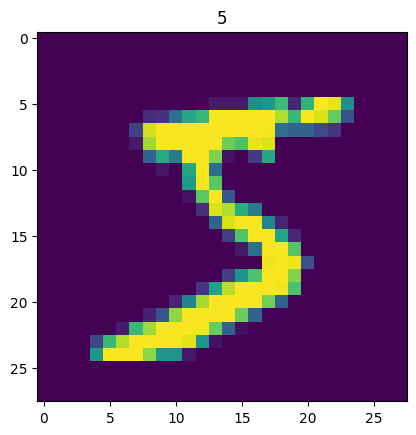

In [3]:
image = trainImg[0]
label = trainLabel[0]

plt.imshow(image)
plt.title(label)
plt.show()

## Image Cleaning Methods

In [4]:
# Method 1 - No Cleaning

def noClean(img):
  return img

In [5]:
# Method 2 - Canny Edge Detection
# This is a commonly used algorithm, in-built in OpenCV, which detects the outlines of the objects (MNIST characters) within the image.

def cannyEdgeMethod(img):
  return cv2.Canny(img, threshold1=50, threshold2=150)

In [6]:
# Method 3 - Gaussian Blurring
# This reduces noise by smoothing the image.

def gaussianBlurMethod(img):
  return cv2.GaussianBlur(img, (5, 5), 0)

In [7]:
# Method 4 - Contrast Adjustment
# This enhances the contrast of the image to increase visibility of the features.

def contrastMethod(img):
  return cv2.equalizeHist(img)

In [8]:
# Method 5 - Crop
# Cropping to focus on the object (character) in the image.

def cropMethod(img):
  img = img[2:26, 2:26]
  return cv2.resize(img, (28, 28)) # re-sizing back to (28,28) for the RNN below

## Simple RNN Model

In [9]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

def initRNN():
    model = Sequential([SimpleRNN(128, input_shape=(28, 28)), Dense(10, activation="softmax")])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [10]:
# Need to make labels Categorical for RNN
from keras.utils import to_categorical

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [11]:
def comparisonModels(cleaningMethod):
  # Apply cleaning method to each image in train/test set
  trainImg2 = np.array([cleaningMethod(img) for img in trainImg])
  testImg2 = np.array([cleaningMethod(img) for img in testImg])

  # Normalising and re-shaping the images
  trainImg2 = (trainImg2/255.0).reshape(-1, 28, 28)
  testImg2 = (testImg2/255.0).reshape(-1, 28, 28)

  # RNN Model
  model = initRNN()
  model.fit(trainImg2, trainLabelCategorical, epochs=5, batch_size=64)

  return model.evaluate(testImg2, testLabelCategorical)

## Evaluation

In [12]:
modelNoCleaning = comparisonModels(noClean)
modelCanny = comparisonModels(cannyEdgeMethod)
modelGaussianBlur = comparisonModels(gaussianBlurMethod)
modelContrast = comparisonModels(contrastMethod)
modelCrop = comparisonModels(cropMethod)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8144 - loss: 0.6182
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9429 - loss: 0.1960
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9538 - loss: 0.1582
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9593 - loss: 0.1402
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9645 - loss: 0.1241
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9657 - loss: 0.1221
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.7017 - loss: 0.8934
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8987 - loss: 0.3205
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9264 - loss: 0.2374
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9386 - loss: 0.2031
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9444 - loss: 0.1798
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.

In [13]:
listAllModels = [modelNoCleaning, modelCanny, modelGaussianBlur, modelContrast, modelCrop]
print(listAllModels)

[[0.0980602577328682, 0.9724000096321106], [0.20453670620918274, 0.9409000277519226], [0.14190542697906494, 0.9589999914169312], [0.10898536443710327, 0.9692999720573425], [0.1667705923318863, 0.9531000256538391]]


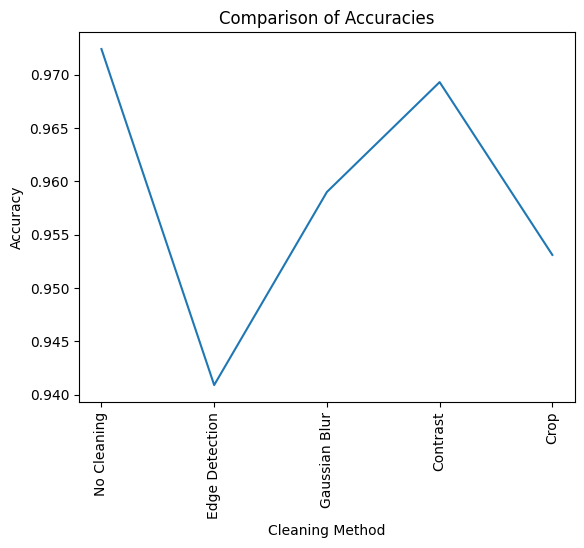

<Figure size 1200x1000 with 0 Axes>

In [14]:
plt.plot(["No Cleaning", "Edge Detection", "Gaussian Blur", "Contrast", "Crop"], [val[1] for val in listAllModels])
plt.title("Comparison of Accuracies")
plt.xlabel("Cleaning Method")
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.figure(figsize=(12, 10))
plt.show()

In the above graph:
- The drop in accuracy for the Gaussian Blur method can probably be attributed to loss of detail due to the smoothing.
- The cropping may have led to outer pixels of the character itself not being taken into account.
- Canny Edge Detection performs the worst, while contrast enhancement performs the best of the cleaning methods.
- Not cleaning the image at all seems like the best option for Keras MNIST (this is a built-in, standard model at the end of the day).